# Analysis of Reports in the City of Zurich

The primary objective of this analysis is to examine the `Züri wie neu` dataset in order to identify spatial and temporal patterns. To achieve this, various visualization techniques will be applied. In addition, a secondary dataset containing waste container locations will be integrated to investigate whether their spatial distribution has an influence on the frequency of waste-related (“Abfall/Sammelstelle”) reports across different districts.

The Züri wie neu dataset contains citizen-reported issues regarding damage and defects in public infrastructure within the City of Zurich. It includes reports of various types of urban maintenance problems, such as potholes in road surfaces, graffiti on public buildings, or vandalized park benches.

In [1]:
import geopandas as gpd
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from esda.moran import Moran
from libpysal.weights import Queen
from scipy.stats import pearsonr, spearmanr, shapiro

## 1. Load the Data 

Before conducting the analysis, the reports data is spatially joined with Zurich's district polygons. This allows each report to be assigned to a specific neighbourhood. Report counts are then standardised by district area (km²) to ensure comparability between districts of different sizes.

In [2]:
# Load preprocessed data
reports_gdf = gpd.read_file("../data/processed/reports_gdf.gpkg")
district_gdf = gpd.read_file("../data/processed/district.gpkg")
lakes_gdf = gpd.read_file("../data/processed/zurichsee.gpkg")

# Spatial Join: assign each report to a district
reports_district_gdf = gpd.sjoin(reports_gdf, district_gdf, how="inner", predicate="within")

# Aggregate number of reports per district
report_counts = reports_district_gdf.groupby("name").size().reset_index(name="count")

# Merge aggregated counts back to district geometries
district_counts_gdf = district_gdf.merge(report_counts, on="name", how="left")

# Handle missing values and compute report denisty per km2
district_counts_gdf["count"] = district_counts_gdf["count"].fillna(0)
district_counts_gdf["density"] = district_counts_gdf["count"] / district_counts_gdf["area_km2"]

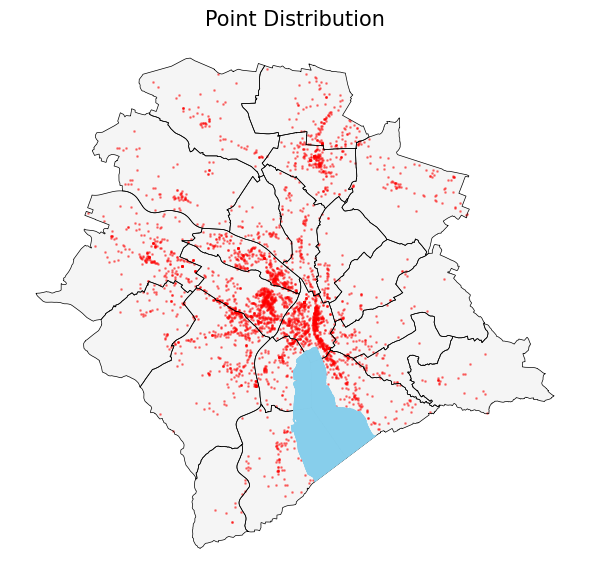

In [ ]:
gastro_gdf = gpd.read_file("../data/raw/gastro.gpkg")
fig, ax = plt.subplots(figsize = (6,6))

district_gdf.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)
gastro_gdf.plot(ax=ax, color="red", markersize=1, alpha=0.4, zorder=2)
district_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)
lakes_gdf.plot(ax=ax, color="skyblue", zorder=4)

ax.axis("off")
ax.set_title("Point Distribution of Gastro", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/point_distribution_gastro.png", dpi=300, bbox_inches="tight")
plt.show()

## 2. Exploratory Spatial Data Analysis (ESDA)
This section explores the spatial distribution of reported incidents across the city of Zurich. The goal is to identify initial spatial patterns, clustering effects, and potential hotspots. To achieve this, three visualization approaches are used: a point distribution map, a choropleth map aggregated by district, and a kernel density estimation (KDE) surface. Together, these methods provide both detailed and smoothed perspectives on the spatial structure of the data.

### 2.1 Point Distribution

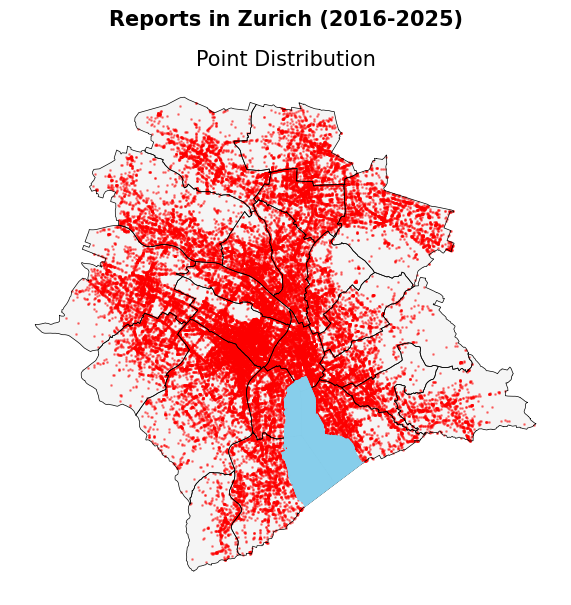

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y=1.001, fontweight="bold")

district_gdf.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)
reports_gdf.plot(ax=ax, color="red", markersize=1, alpha=0.4, zorder=2)
district_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)
lakes_gdf.plot(ax=ax, color="skyblue", zorder=4)

ax.axis("off")
ax.set_title("Point Distribution", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/point_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The point distribution map shows the raw locations of all reported incidents across the city. Without any aggregation, individual events are visible in their exact spatial context. A clear concentration of reports can already be observed in the central parts of Zurich, while peripheral areas (molstly covered by forests) appear significantly less dense.

### 2.2 Choropleth (by district density)

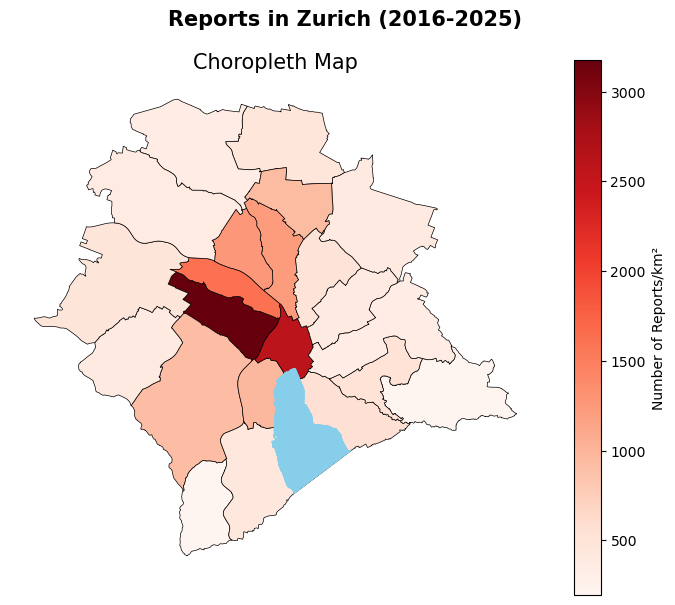

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y=1.001, fontweight="bold")

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

district_counts_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Number of Reports/km²"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Choropleth Map", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/choropleth_map.png", dpi=300, bbox_inches="tight")
plt.show()

The choropleth map aggregates the number of reports at the district level normalized by area (km²). This adjustment allows for meaningful comparison between districts of different sizes. The resulting pattern highlights strong spatial inequalities, with central districts (mostly Aussersihl, Altstadt and Industriequartier) showing substantially higher report densities than outer residential areas. This suggests that urban core areas experience a higher concentration of reported issues, likely due to more intensive public space usage.

### 2.3 Kernel Density Estimate (KDE) Heatmap
The KDE heatmap provides a smoothed representation of reporting intensity across space. Instead of showing discrete points, it estimates continuous density surfaces, making clusters and hotspots more visually apparent. While this approach is useful for identifying general spatial trends, it introduces smoothing effects that may obscure fine-scale variation. Therefore, the results should be interpreted as indicative patterns rather than precise measurements.

The bandwidth parameter was set to `bw_adjust=0.5`, which produces a finer-grained density surface compared to the default value of 1.0. This value was chosen through visual inspection of several candidate values, selecting the one that best balanced local detail and visual clarity without over-smoothing the spatial pattern.

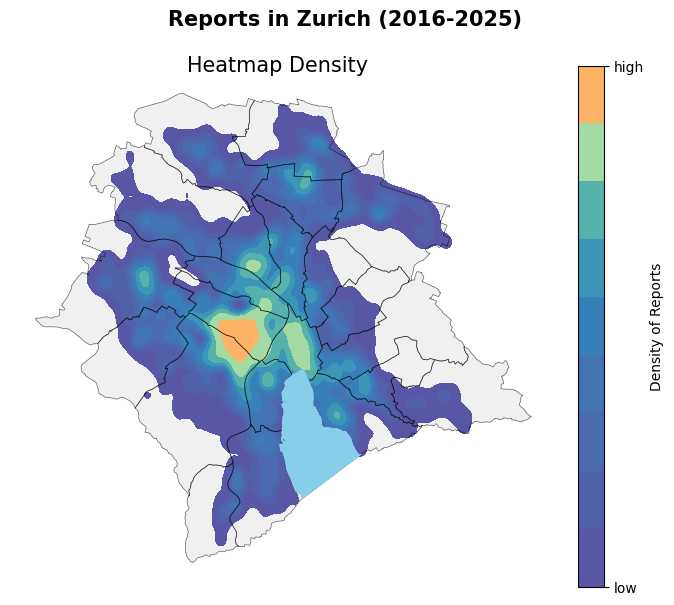

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))
fig.suptitle("Reports in Zurich (2016-2025)", fontsize=15, x=0.5, y=1.001, fontweight="bold")

district_gdf.plot(ax=ax, color="#f0f0f0", edgecolor="none")

sns.kdeplot(
    x=reports_gdf.e,
    y=reports_gdf.n,
    ax=ax,
    cmap="Spectral_r",
    fill=True,
    cbar=True,
    cbar_kws={"label": "Density of Reports"},
    bw_adjust=0.5)

cbar = ax.collections[-1].colorbar
vmin, vmax = cbar.ax.get_ylim()
cbar.set_ticks([vmin, vmax])
cbar.set_ticklabels(["low", "high"])

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)
district_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, alpha=0.6, zorder=1)

ax.axis("off")
ax.set_title("Heatmap Density", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/heatmap_density.png", dpi=300, bbox_inches="tight")
plt.show()

The heatmap reveals a clear concentration hotspot between Aussersihl and Wiedikon. Elevated report densities are also visible in the Altstadt area. As discussed above, report density is considerably higher in the central districts of the city of Zurich.

### 2.4 Histogram of Number of Reports per District

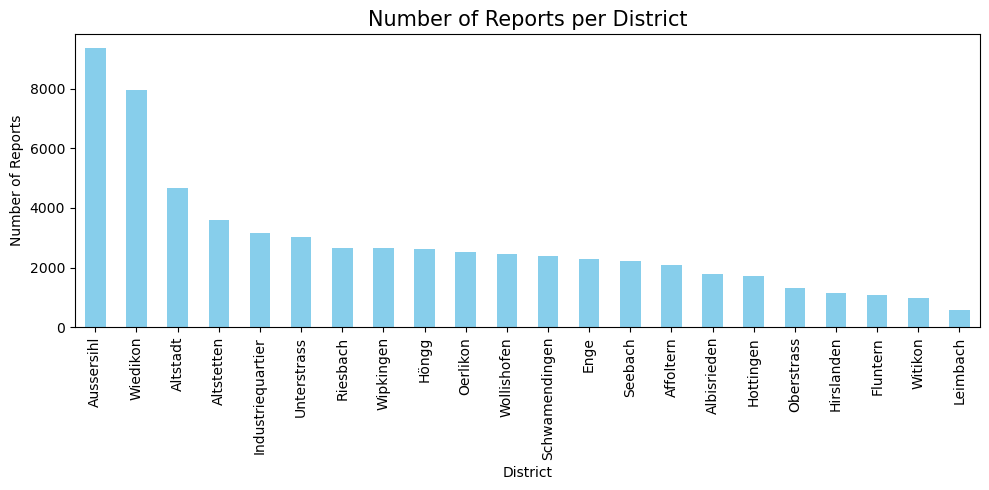

In [6]:
fig, ax = plt.subplots(figsize=(10,5))

reports_district_gdf["name"].value_counts().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per District", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("District")

plt.tight_layout()
plt.savefig("../outputs/reports_per_district.png", dpi=300, bbox_inches="tight")
plt.show()

The histogram shows a strongly uneven distribution of reported incidents across Zurich’s districts. A small number of districts clearly stand out as outliers, with Aussersihl showing the highest number of reports, followed by Wiedikon and, to a lesser extent, the Altstadt. These districts have significantly higher values compared to the rest of the city.

In contrast, most other districts are relatively close to each other in terms of total report counts, forming a fairly compact middle range without strong variation. At the lower end of the distribution, Leimbach records the lowest number of reports.

Overall, the pattern suggests that reporting activity is highly concentrated in a few central or densely used districts, while the majority of districts experience comparatively similar and lower levels of reported incidents.

### 2.5 Spatial Autocorrelation (Global Moran's I)
Spatial autocorrelation measures whether similar values tend to occur close to each other in geographic space or whether they are randomly distributed. In this analysis, Global Moran’s I is used to test whether the density of reports across Zurich’s districts shows a statistically structured spatial pattern. The statistic compares the value of each district with the values of its neighboring districts based on a spatial weights matrix. A positive value indicates clustering of similar values, while a value close to zero suggests randomness. However, with only 34 spatial units, the statistical power is limited and results should be interpreted with caution.

Queen contiguity is a method for defining spatial neighbors in geographic data. Two areas are considered neighbors if they share either a common boundary or a single corner point.

In [7]:
# Spatial weights
w = Queen.from_dataframe(district_counts_gdf, use_index = False)
w.transform = "r"

# Variable
y = district_counts_gdf["density"].values

# Moran's I
moran = Moran(y, w)

print(f"Moran's I: {moran.I:.3f}")
print(f"p-value:   {moran.p_sim:.3f}")

Moran's I: 0.233
p-value:   0.023


The results show a Moran’s I value of `0.233` with a p-value of approximately `0.027` This indicates a statistically significant positive spatial autocorrelation in the distribution of reports across Zurich’s districts. In other words, districts with similar report densities are not randomly scattered but tend to be located near each other.

This pattern suggests the presence of spatial clustering, where high-report areas are concentrated in central urban districts, while lower-report areas are more common in peripheral districts. Although the strength of the autocorrelation is moderate rather than strong, the result confirms that the observed spatial pattern is systematic and not due to random variation. The p-value is derived from a Monte Carlo permutation test and may vary slightly between runs due to its stochastic nature.

### 2.6 Which neighbourhoods receive the highest number of reports?

Examining the three maps and the histogram reveals that the Aussersihl district consistently shows the highest level of reported incidents. In terms of density (reports per km²), it is followed by the Altstadt, which also exhibits very high values compared to the rest of the city. Overall, a clear spatial gradient emerges, with central districts showing significantly higher reporting intensities than peripheral neighbourhoods.

It is important to distinguish between the different representations. While the choropleth map displays report density (normalised by area), the histogram shows absolute counts per district. This leads to slight differences in ranking. For example, Altstadt appears particularly prominent in terms of density due to its small geographical size and high concentration of reports, whereas districts such as Wiedikon show relatively higher absolute counts in the histogram because of their larger area.

Despite these differences, both perspectives consistently highlight a strong concentration of reports in central urban areas. This pattern is likely related to the higher intensity of land use in the city centre, including business activity, nightlife, and tourism, which increases the likelihood of reportable incidents compared to more residential outer districts.

Having established the spatial distribution of reports across Zurich's districts, the following chapter investigates whether these patterns have remained stable over time or whether reporting behaviour has changed between 2016 and 2025.

## 3. Temporal Evolution of Reporting Activity
The temporal analysis is used to examine how reporting activity in Zurich changes over time and whether any long-term trends can be observed. By combining yearly choropleth maps with aggregated annual counts, it becomes possible to compare both the spatial and temporal dimensions of the dataset.
### 3.1 Yearly Choropleths
To better understand how reporting behaviour changed over time, yearly report densities are calculated and visualised for each district between 2016 and 2025.

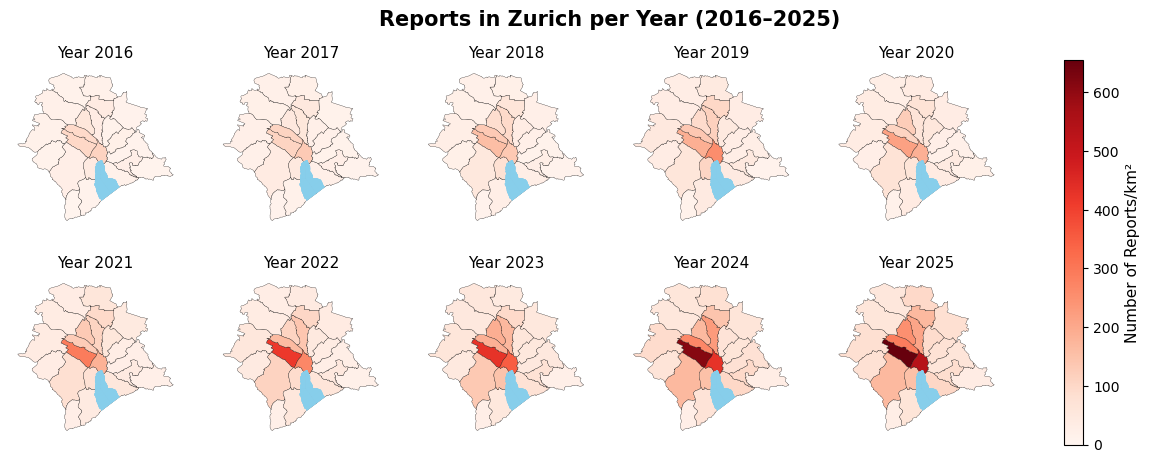

In [8]:
# Group by year and calculate the number of reports
yearly_counts = reports_district_gdf.groupby(["year", "name"]).size().reset_index(name="count")

# Standardisation
yearly_density = yearly_counts.merge(district_gdf[["name", "area_km2"]], on="name")
yearly_density["density"] = yearly_density["count"] / yearly_density["area_km2"]

# Max. density
max_yearly_density = yearly_density["density"].max()

# Create choropleth maps
fig, axs = plt.subplots(2,5, figsize=(16,5))
axs = axs.flatten()
fig.suptitle("Reports in Zurich per Year (2016–2025)", fontsize=15, fontweight="bold")

years = range(2016, 2026)

for i, year in enumerate(years):
    ax = axs[i]
    counts_year = yearly_counts[yearly_counts["year"] == year]
    yearly_map_gdf = district_gdf.merge(counts_year, on="name", how="left")

    yearly_map_gdf["density"] = yearly_map_gdf["count"] / yearly_map_gdf["area_km2"]
    
    yearly_map_gdf.plot(column="density", cmap="Reds", vmin=0, vmax=max_yearly_density,  edgecolor="black", linewidth=0.2, ax=ax)

    lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)
    
    ax.set_title(f"Year {year}", fontsize=11)
    ax.axis("off")

sm = plt.cm.ScalarMappable(cmap="Reds", norm=plt.Normalize(vmin=0, vmax=max_yearly_density))
cbar = fig.colorbar(sm, ax=axs)
cbar.set_label("Number of Reports/km²", fontsize=11)

plt.savefig("../outputs/reports_yearly_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()


### 3.2 Reports per Year Histogram

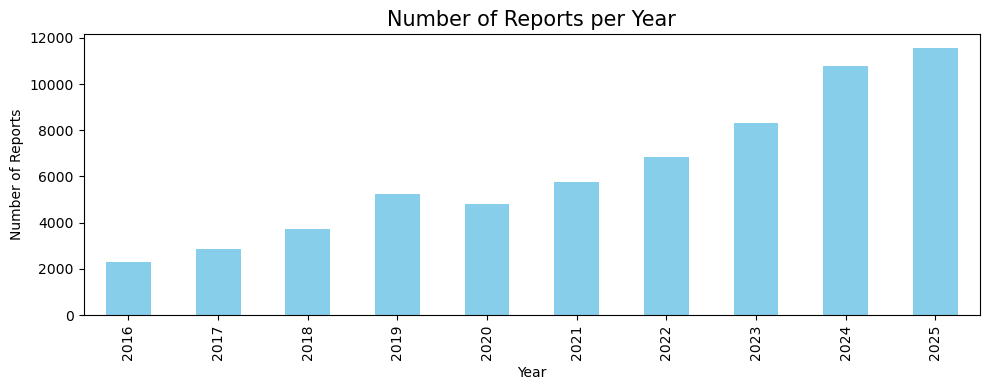

In [9]:
fig, ax = plt.subplots(figsize=(10,4))

reports_gdf["year"].value_counts().sort_index().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per Year", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("Year")

plt.tight_layout()
plt.savefig("../outputs/reports_per_year.png", dpi=300, bbox_inches="tight")
plt.show()

The maps and histogram above provide an initial visual impression of how reporting activity has evolved over time. A detailed interpretation of both the spatial and temporal trends is provided in section below.

### 3.3 How does the number of reports vary over time or between neighbourhoods?

The provided series of choropleth maps illustrates the evolution of reporting density (reports per km²) and the histogram illustrates the absolute counts of reports across Zurich's districts over a ten-year period. The data reveals two primary trends. A significant temporal increase in total reports and a persistent geographical concentration in the city center.

There is a striking upward trend in the number of reports over the decade. In the early years (2016–2018), the maps appear relatively pale, indicating a low reporting density across most districts. However, starting in 2019, the color intensity increases significantly. By 2024, the density in the most active areas has more than doubled compared to 2016, reaching peaks of over 600 reports per km². The fact that 2025 already shows such high values suggests that the frequency of reporting is continuing to accelerate.

Despite the overall increase in volume, the spatial distribution remains remarkably consistent. The "hotspots" are invariably located in the central districts, particularly in Aussersihl and the Altstadt. These areas consistently show the highest density, represented by the deep red shades. In contrast, the peripheral and more residential districts (such as Witikon, Höngg, or Affoltern) remain light-colored throughout the entire period, indicating that the challenges being reported are predominantly an urban-center phenomenon.

This overall increase in the number of reports might be a result of several factors:
- The rising popularity of mobile reporting due to the digitalisation makes it easier for citizens to report infrastructure issues, waste, or maintenance needs.
-  As the city center become more densely used for work, nightlife, and tourism, the likelihood of reportable incidents (e.g., littering, noise, or damage) increased.
- A growing sense of civic responsibility and higher expectations regarding urban cleanliness and maintenance likely contribute to the surge in data points.

## 4. Overview of Report Types
Each report in the Züri wie neu dataset is assigned a service code, which categorises the type of infrastructure issue being reported. Examples include categories such as graffiti, damaged road surfaces, or waste-related problems. These codes allow for a systematic classification of urban maintenance issues across the city.
### 4.1  Histogram of Number of Reports per Service Code


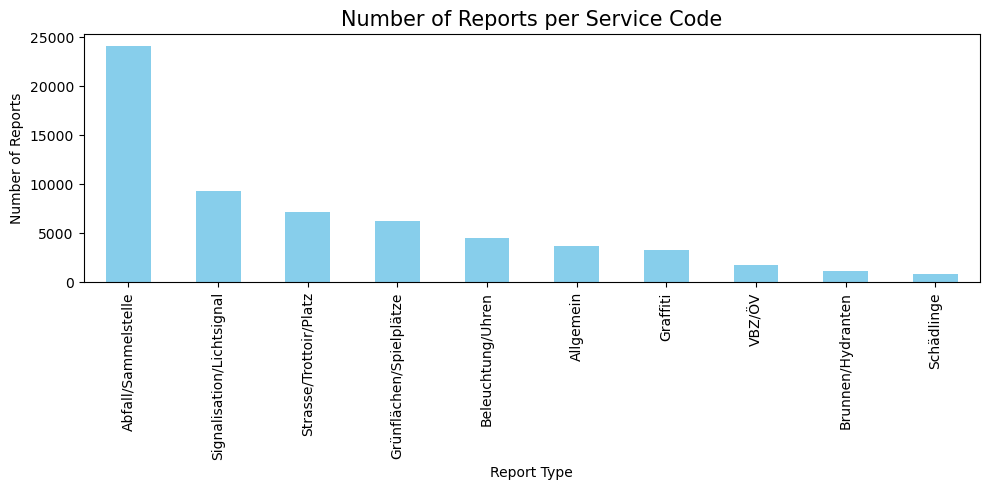

In [17]:
fig, ax = plt.subplots(figsize=(10,5))

reports_gdf["service_code"].value_counts().plot(kind="bar", ax=ax, color="skyblue")

ax.set_title("Number of Reports per Service Code", fontsize=15)
ax.set_ylabel("Number of Reports")
ax.set_xlabel("Report Type")

plt.tight_layout()
plt.savefig("../outputs/reports_per_service_code.png", dpi=300, bbox_inches="tight")
plt.show()

The histogram shows the number of reports per service code recorded between 2016 and 2025. Waste-related reports ("Abfall/Sammelstelle") clearly dominate all other categories by a substantial margin, accounting for nearly 25,000 reports. The second most frequent categories ("Signalisation/Lichtsignal", "Strasse/Trottoir/Platz") record considerably lower counts. This imbalance suggests that waste management represents the most pressing urban maintenance concern reported by Zurich's citizens.

### 4.2 Spatial Distribution of Waste-Related Reports

The spatial distribution of waste-related reports closely mirrors the overall reporting pattern. Aussersihl exhibits the highest concentration by a significant margin, exceeding 2'000 reports per km², followed by the surrounding districts. To determine whether this trend is linked to the availability of disposal infrastructure, the following section will analyze the distribution of waste containers in more detail.

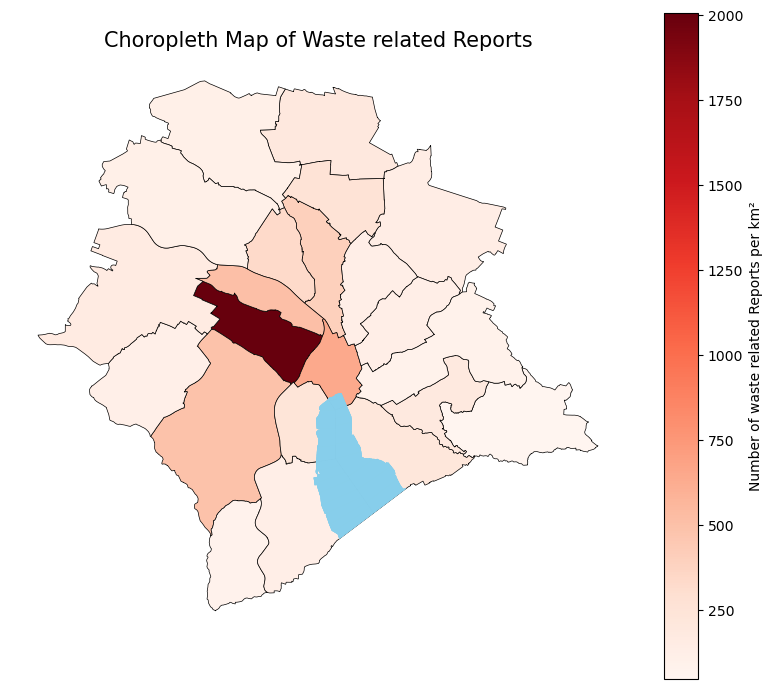

In [11]:
# Choropleth Map of waste related Reports
fig, ax = plt.subplots(figsize=(8,7))

# Filter waste-related reports 
waste_reports_gdf = reports_district_gdf[reports_district_gdf["service_code"] == "Abfall/Sammelstelle"]

# Aggregate by district
waste_counts = (waste_reports_gdf.groupby("name").size().reset_index(name="count"))

# Merge with district geometries
district_waste_gdf = district_gdf.merge(waste_counts, on="name", how="left")

# Standardization
district_waste_gdf["count"] = district_waste_gdf["count"].fillna(0)
district_waste_gdf["density"] = district_waste_gdf["count"] / district_waste_gdf["area_km2"]

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

district_waste_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Number of waste related Reports per km²"},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Choropleth Map of Waste related Reports", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/waste_reports_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Waste Related Reports compared with Waste Containers
Having identified waste-related reports ("Abfall/Sammelstelle") as the dominant report category, this chapter investigates whether the spatial distribution of waste containers across Zurich's districts is associated with the frequency of waste-related reports. One could assume that districts with a lower number of waste containers tend to have a higher number of waste-related reports.

The analysis proceeds in three steps. First, the spatial distribution of waste containers is examined. Second, the relationship between container density and report density is visualised through a regression plot and third, a formal correlation analysis is conducted to quantify the strength and direction of this association.
### 5.1 Spatial Distribution of Waste Containers
Before examining the relationship between waste containers and waste-related reports, the spatial distribution of containers across Zurich is explored. A point distribution map shows the raw locations of all registered waste containers, while a choropleth map aggregated by district provides a normalised view of container density per km². A bar chart additionally summarises the absolute container counts per district.

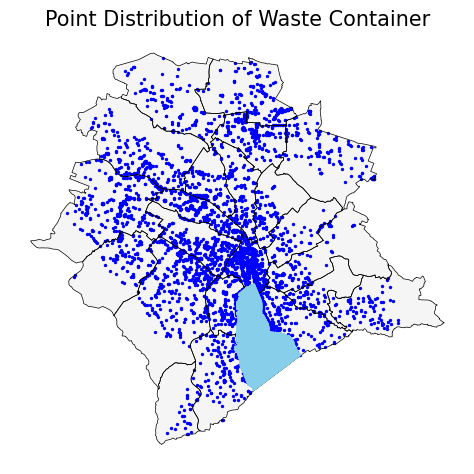

In [12]:
waste_containers = gpd.read_file("../data/raw/abfallgefaesse.gpkg")
waste_containers = waste_containers.to_crs(epsg=2056)

# Point Distribution Map
fig, ax = plt.subplots(1,1, figsize=(7, 5))

district_gdf.plot(ax=ax, color="whitesmoke", linewidth=0.5, zorder=1)

waste_containers.plot(
    ax=ax,
    color="blue",
    markersize=2,
    zorder=2,
    label="Waste container")

lakes_gdf.plot(ax=ax, color="skyblue", zorder=4)

district_gdf.boundary.plot(ax=ax, color="black", linewidth=0.5, zorder=3)

ax.axis("off")
ax.set_title("Point Distribution of Waste Container", fontsize=15)

plt.tight_layout()
plt.savefig("../outputs/waste_container_points.png", dpi=300, bbox_inches="tight")
plt.show()

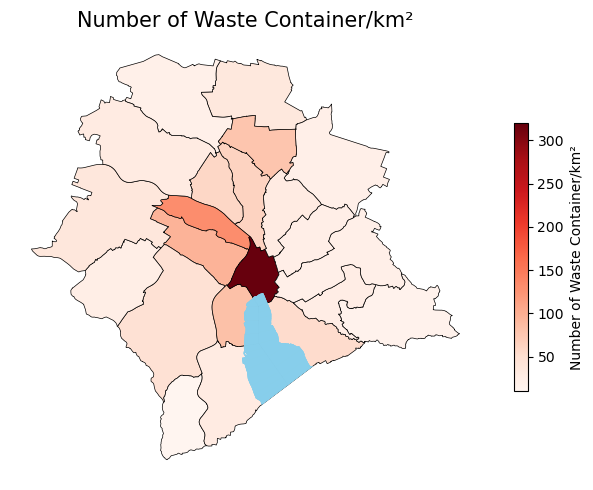

In [13]:
# Spatial Join
waste_container_district_gdf = gpd.sjoin(waste_containers, district_gdf, how="inner", predicate="within")
waste_container_counts = waste_container_district_gdf.groupby("name").size().reset_index(name="count")
district_waste_container_counts_gdf = district_gdf.merge(waste_container_counts, on="name", how="left")

# Standardization
district_waste_container_counts_gdf["density"] = district_waste_container_counts_gdf["count"] / district_waste_container_counts_gdf["area_km2"]

fig, ax = plt.subplots(1,1, figsize=(7, 5))

lakes_gdf.plot(ax=ax, color="skyblue", zorder=2)

district_waste_container_counts_gdf.plot(
    column="density",
    cmap="Reds",
    legend=True,
    legend_kwds={"label": "Number of Waste Container/km²", "orientation": "vertical", "shrink": 0.6},
    edgecolor="black",
    linewidth=0.5,
    ax=ax,
    zorder=1)

ax.set_title("Number of Waste Container/km²", fontsize=15)
ax.axis("off")

plt.tight_layout()
plt.savefig("../outputs/waste_container_choropleth.png", dpi=300, bbox_inches="tight")
plt.show()

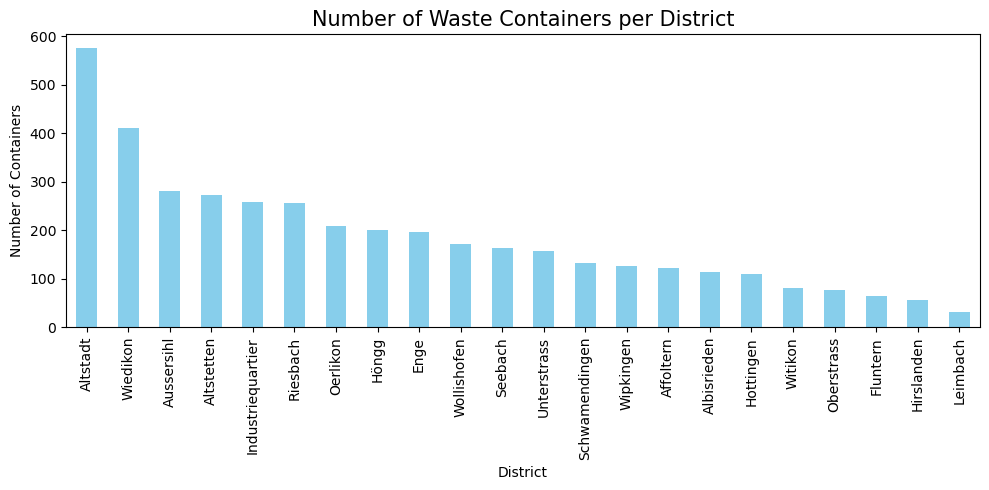

In [14]:
waste_container_counts_per_district = waste_container_district_gdf.groupby("name").size().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

waste_container_counts_per_district.plot(
    kind="bar", 
    ax=ax, 
    color="skyblue")

ax.set_title("Number of Waste Containers per District", fontsize=15)
ax.set_ylabel("Number of Containers")
ax.set_xlabel("District")

plt.tight_layout()
plt.savefig("../outputs/waste_containers_per_district.png", dpi=300, bbox_inches="tight")
plt.show()

The point distribution map reveals that waste containers are predominantly concentrated in the central districts, with a noticeably sparser coverage in the outer, more residential and forested areas of the city. The choropleth map confirms this pattern. The central districts such as Aussersihl and Wiedikon exhibit by far the highest container densities, while peripheral districts like Leimbach or Hirslanden show comparatively low values. The bar chart further illustrates that the absolute number of containers per district follows a similar spatial gradient observed in the report data, suggesting a possible structural link between waste infrastructure provision and reporting activity.

### 5.2 Relationship Between Waste Containers and Waste Reports
To investigate whether districts with more waste infrastructure also tend to have less waste-related reports, the densities of waste containers and waste-related reports are plotted against each other in a regression plot. Each point represents one district, allowing the relationship between the two variables to be assessed visually before proceeding to a formal statistical test.

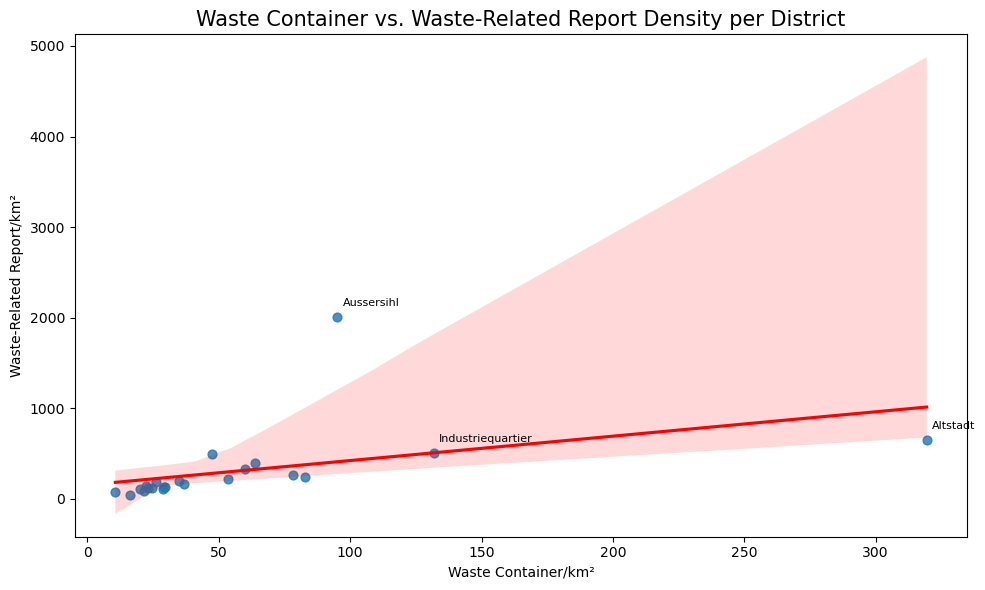

In [ ]:
# Regressionplot Waste Container vs. Report Density per District
df_container = district_waste_container_counts_gdf[["name", "density"]].rename(columns={"density": "container_density"})
df_reports = district_waste_gdf[["name", "density"]].rename(columns={"density": "report_density"})
analysis_df = df_container.merge(df_reports, on="name")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=analysis_df,
    x="container_density",
    y="report_density",
    scatter_kws={"s":40},
    line_kws={"color":"red"})

for i, row in analysis_df.iterrows():
    if row["report_density"] > 500 or row["container_density"] > 200:
        plt.text(
            row["container_density"]+2,
            row["report_density"]+120,
            row["name"],
            fontsize=8)
        
plt.title("Waste Container vs. Waste-Related Report Density per District", fontsize=15)
plt.xlabel("Waste Container/km²")
plt.ylabel("Waste-Related Report/km²")

plt.tight_layout()

plt.savefig("../outputs/scatter_container_reports.png", dpi=300)
plt.show()

The regression plot visualises the relationship between waste container density and waste-related report density across Zurich's districts. At first glance, the upward-sloping trend line suggests a positive association that districts with more waste infrastructure tend to also record more waste-related reports. However, the plot also reveals a critical issue: Aussersihl, Industriequartier and Altstadt can be identified as stong outliers.

Aussersihl stands out most strikingly, with a waste-related report density of approximately 2,000 reports/km² despite a container density of only around 90 containers/km². This represents a disproportionately high report density relative to its infrastructure. Altstadt, on the other hand, shows the highest container density in the dataset (over 300/km²) but a comparatively moderate report density of around 650/km². Industriequartier similarly deviates from the trend with a high container density but a relatively low report count. The enormous confidence interval (shaded area) further illustrates how strongly these three outliers inflate the uncertainty of the regression estimate, rendering the linear fit unreliable as a descriptive tool.

### 5.3 Correlation Analysis

In [16]:
# Shapiro-Wilk Test
stat1, p_sw1 = shapiro(analysis_df["container_density"])
stat2, p_sw2 = shapiro(analysis_df["report_density"])

print(f"Shapiro-Wilk container density: W = {stat1:.3f}, p = {p_sw1:.3f}")
print(f"Shapiro-Wilk report density:    W = {stat2:.3f}, p = {p_sw2:.3f}")

# Pearson
r, p = pearsonr(analysis_df["container_density"], analysis_df["report_density"])
print(f"Pearson:  r = {r:.3f}, p = {p:.3f}")

# Spearman
r_sp, p_sp = spearmanr(analysis_df["container_density"], analysis_df["report_density"])
print(f"Spearman: r = {r_sp:.3f}, p = {p_sp:.3f}")

Shapiro-Wilk container density: W = 0.603, p = 0.000
Shapiro-Wilk report density:    W = 0.540, p = 0.000
Pearson:  r = 0.431, p = 0.045
Spearman: r = 0.919, p = 0.000


Before computing the correlation, the distributional assumptions were assessed using the Shapiro-Wilk test. Both variables deviated significantly from a normal distribution (p < 0.05), which is consistent with the visual inspection of the scatter plot revealing two extreme outliers (Aussersihl and Altstadt). Since Pearson's r assumes normality and is sensitive to outliers, Spearman's rank correlation is used as the primary measure.

Spearman's rank correlation revealed a very strong positive association between waste container density and waste-related report density across Zurich's districts (r = 0.92, p < 0.001). For reference, Pearson's r yields a substantially lower moderate correlation of 0.43 (p = 0.045). This discrepancy illustrates how strongly Pearson is distorted by the two outlier districts, which exert disproportionate leverage on the mean-based calculation. Spearman, by working with ranks, accounts for these extreme values without excluding them from the analysis, making it the more appropriate and robust choice here.

The positive direction of the correlation may appear counterintuitive at first glance, as one might expect higher container availability to reduce waste-related reports. However, this reasoning would only hold if container density were the sole driver of reporting activity. In reality, both variables are primarily shaped by the same underlying factor: urban activity intensity. Districts with high pedestrian traffic, nightlife, and commercial use tend to have both more waste infrastructure and more reportable incidents, regardless of whether the infrastructure is sufficient to meet demand. The positive correlation therefore does not imply that more containers cause more reports, but rather that both variables are symptoms of the same urban condition. A causal interpretation is thus not warranted.

## 6. Conclusion and Limitations

The analysis reveals clear and consistent spatial inequalities in reporting activity across Zurich. Central districts exhibit substantially higher report densities compared to peripheral residential areas, indicating a strong concentration of urban maintenance issues in the city centre. Over time, the data also shows a marked increase in total reports, suggesting growing reporting activity likely influenced by digital reporting platforms, intensified urban usage, and shifting civic engagement.

The investigation of waste-related reports further confirms this spatial pattern. These reports are highly concentrated in central districts and closely align with areas of high pedestrian activity and urban density. The correlation analysis between waste container density and waste-related report density demonstrates a very strong positive association (Spearman r = 0.92, p < 0.001). Pearson's r yielded a substantially lower value of 0.43, which can be attributed to its sensitivity to the two extreme outlier districts (Aussersihl and Altstadt) that exert disproportionate leverage on the mean-based calculation. Spearman's rank correlation is therefore the more appropriate measure here, as it accounts for these extremes without excluding them from the analysis.

The positive direction of this association may appear counterintuitive, as one might expect higher container availability to reduce waste-related reports. However, both variables are primarily driven by the same underlying factor: urban activity intensity. Districts with high pedestrian traffic, nightlife, and commercial use tend to have both more waste infrastructure and more reportable incidents, regardless of whether that infrastructure is sufficient to meet demand. The correlation therefore reflects shared urban characteristics rather than a direct relationship between containers and reports, and a causal interpretation is not warranted.
Spatial autocorrelation analysis (Global Moran's I = 0.233, p = 0.027) confirms that reporting activity is significantly clustered in space, particularly in central urban districts. Given the relatively small number of spatial units (n = 34), this result should be interpreted with appropriate caution regarding statistical power, but it nonetheless reinforces the finding that urban structure strongly shapes where reports occur.

Several limitations should be considered. The analysis is aggregated at district level, which may hide finer spatial variations within districts (modifiable areal unit problem). The small number of spatial units also affects the stability of statistical measures such as Moran's I and the Spearman correlation. The analysis is furthermore purely descriptive and does not establish causality between any of the examined variables.

Finally, reporting behaviour itself may be influenced by external factors such as digital accessibility, awareness of reporting tools, and changes in administrative processes over time. Increases in reported incidents may therefore partially reflect changes in reporting behaviour rather than actual changes in infrastructure conditions.